# CAMELS: Climate Indices from EMO1 time series
***

**_Autor:_** Chus Casado Rodríguez<br>
**_Fecha:_** 18-06-2026<br>

**Introduction:**<br>
This notebook creates the static attributes related to the areal meteorological time series.

In [1]:
import pandas as pd
import geopandas as gpd
import xarray as xr
from tqdm.auto import tqdm

from reservoirs_lshm.utils.plots import plot_attributes
from reservoirs_lshm.utils.utils import duration_precip_indices

from ocab.config import Config
import ocab.variables as vars

## Configuration

In [2]:
cfg = Config('config_CAMELS_v200.yml')
basin_id_field = 'gauge_id'

# path where the meteo time series were extracted
path_meteo = cfg.path_dataset / 'preprocessing' / 'timeseries' / 'meteo'

# save plots in folder
path_plots = cfg.path_plots / 'attributes'
path_plots.mkdir(parents=False, exist_ok=True)

print(f'Attribute tables will be saved in {cfg.path_attributes}')

Attribute tables will be saved in /home/casadoj/Data/CAMELS-ES/v2_0_0/attributes


## Data

### Basin outlets

In [3]:
# load basin outlets
outlets = gpd.read_file(cfg.path_gis / 'stations.geojson').set_index('id')
print(f'{len(outlets)} basin outlets')

1117 basin outlets


### Meteorology

In [15]:
# load meteo time series
meteo = []
for ID in tqdm(outlets.index):
    # read time series
    try:
        df = pd.read_parquet(path_meteo / 'ROCIO-IBEB' / f'{ID}.parquet').loc[ID]
    except:
        df = pd.read_parquet(path_meteo / 'EMO1' / f'{ID}.parquet').loc[ID]
    
    # rename columns
    df.rename(columns=vars.RENAME, inplace=True)

    # calculate mean temperature
    if 'temp_degC' not in df.columns:
        df['temp_degC'] = df[['temp_max_degC', 'temp_min_degC']].mean(axis=1)
        df.drop(columns=['temp_max_degC', 'temp_min_degC'], inplace=True)
    
    # keep only average values
    df = df[['precip_mm', 'temp_degC', 'pet_mm']]
    
    # remove units from col names
    df.columns = [col.split('_')[0] for col in df.columns]

    # convert to xarray.Dataset
    ds = xr.Dataset.from_dataframe(df)
    ds = ds.assign_coords(id=ID).expand_dims('id')

    meteo.append(ds)
meteo = xr.concat(meteo, dim='id', join='outer')


# compute precipitation as snowfall
meteo['snow'] = meteo['precip'].where(meteo['temp'] > 1, 0)

  0%|          | 0/1117 [00:00<?, ?it/s]

## Attributes

### Compute

In [16]:
# average of all meteo variables
attrs = meteo.mean('time').to_pandas()
attrs.columns = [f'{col}_mean' for col in attrs.columns]
attrs.index.name = outlets.index.name

# indices
attrs['aridity'] = attrs.precip_mean / attrs.pet_mean
attrs['frac_snow'] = attrs.snow_mean / attrs.precip_mean
attrs['moisture_index'] = attrs.precip_mean - attrs.pet_mean
precip_monthly = meteo['precip'].resample({'time': 'MS'}).sum().groupby('time.month').mean()
precip_annual = meteo['precip'].resample({'time': 'YS'}).sum().mean('time')
attrs['seasonality'] = ((precip_monthly.max('month') - precip_monthly.min('month')) / precip_annual).to_pandas()

# high and dry precipitation indices
precip_extremes = {
    'high': 20, # mm
    'low': 1 # mm
}
for key, value in precip_extremes.items():
    if key == 'high':
        mask_precip = meteo['precip'] > value
    elif key == 'low':
        mask_precip = meteo['precip'] < value
    attrs[f'{key}_precip_freq'] = mask_precip.sum('time') / len(meteo.time)
    attrs[f'{key}_precip_dur'] = duration_precip_indices(mask_precip.to_pandas().transpose())

### Plot

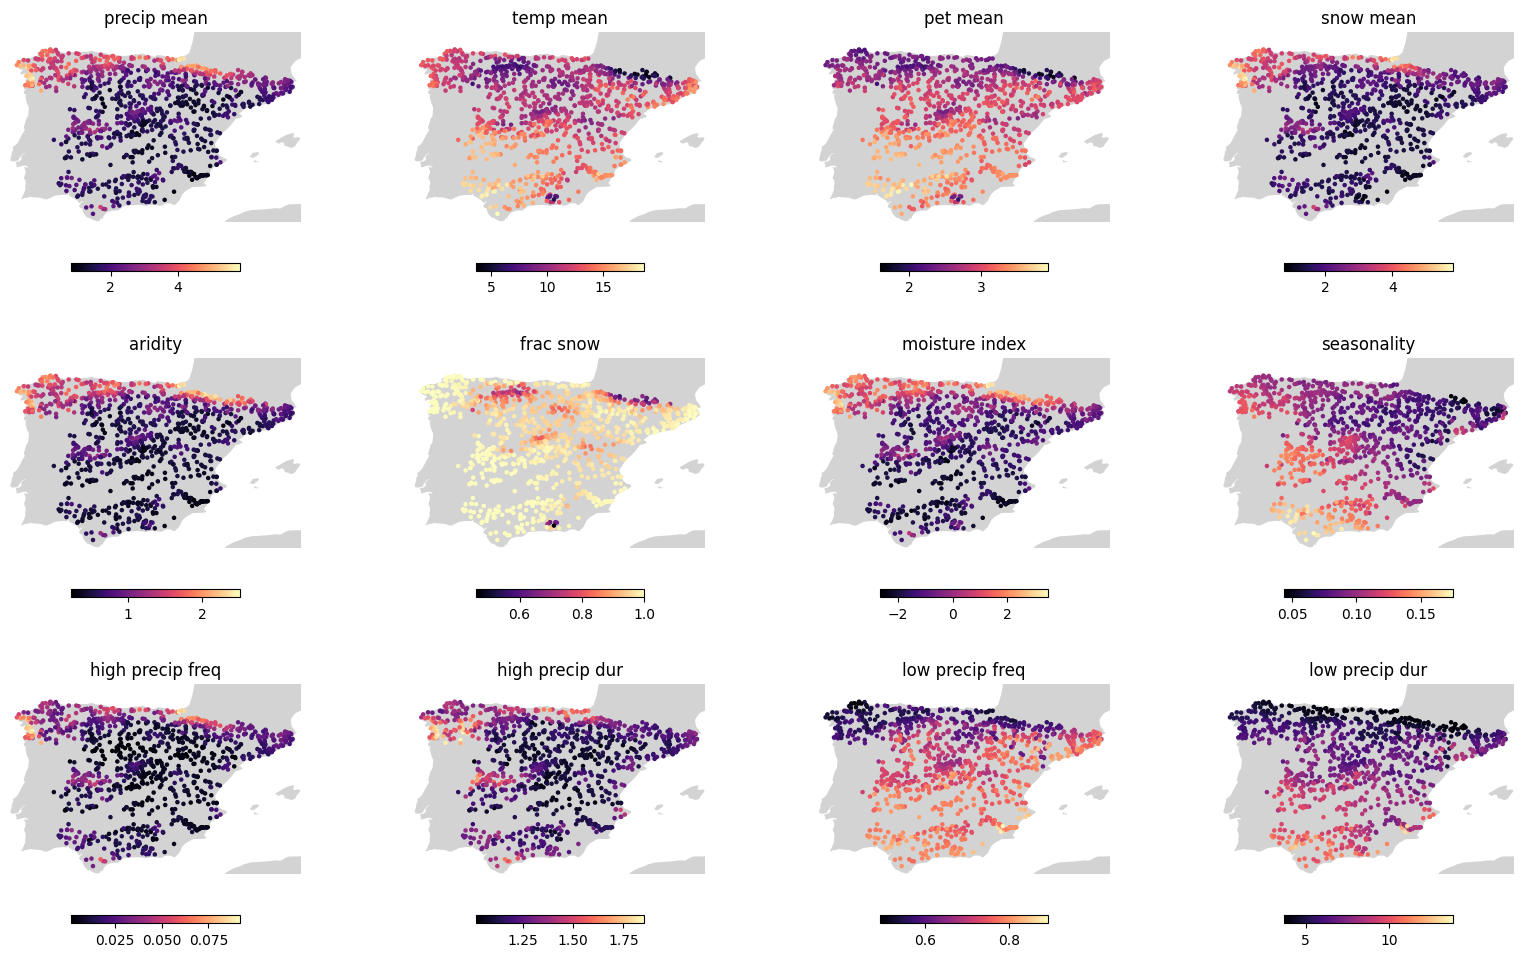

In [17]:
# plot attributes
r = 5
plot_attributes(
    attrs,
    outlets.geometry.x,
    outlets.geometry.y,
    ncols=4,
    extent=[-9.5, 3.5, 36, 44.5],
    save=path_plots / f'maps_climate.jpg'
)

### Export

In [18]:
# set index and sort
attrs.sort_index(axis=0, inplace=True)
attrs.index = [f'{cfg.prefix}_{ID}' for ID in attrs.index]
attrs.index.name = basin_id_field
print('{0} climate indices define the climatology of {1} catchments'.format(*attrs.shape[::-1]))

# export
attrs.to_csv(cfg.path_attributes / 'climate_indices.csv', float_format='%.6f')

12 climate indices define the climatology of 1117 catchments
